# Lab 3 assignment

Dataset link: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews

In [1]:
# !pip install pandas spacy matplotlib seaborn wordcloud scikit-learn gensim nltk
# !python -m spacy download en_core_web_sm

In [ ]:
import pandas as pd
import spacy
import re

# Load the dataset (Make sure 'Reviews.csv' is in your working directory)
# We limit to 100 rows to ensure it runs smoothly on most machines
df = pd.read_csv("Reviews.csv", nrows=100)
df.head()

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\jimmy\Documents\Tài liệu\vital docs\CODING\Python\dias\lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [ ]:
df.shape

(100, 10)

#### 1️⃣ Text Preprocessing
🧹 Clean and prepare the text by applying:

- Tokenisation
-	Lowercasing
-	Stopword removal
-	Lemmatization


In [ ]:

# Rule: Do not use NaN values—filter or replace missing data
df = df.dropna(subset=['Text', 'Score', 'Time'])

# Load spaCy English model
nlp = spacy.load("en_core_web_sm")

# Define preprocessing function
def preprocess_text(text):
    # Process text with spaCy
    doc = nlp(text.lower()) # Lowercasing
    
    # Tokenization, Stopword removal, and Lemmatization
    tokens = [
        token.lemma_ for token in doc 
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    return " ".join(tokens)

# Apply preprocessing to the Text column
print("Preprocessing text... this may take a couple of minutes.")
df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

print("Preprocessing complete! Here is a sample:")
print(df[['Text', 'Cleaned_Text']].head(3))

Preprocessing text... this may take a couple of minutes.
Preprocessing complete! Here is a sample:
                                                Text  \
0  I have bought several of the Vitality canned d...   
1  Product arrived labeled as Jumbo Salted Peanut...   
2  This is a confection that has been around a fe...   

                                        Cleaned_Text  
0  buy vitality can dog food product find good qu...  
1  product arrived label jumbo salt peanut peanut...  
2  confection century light pillowy citrus gelati...  


#### 2️⃣ Text Representation
Represent the text using:

-	**BoW**: Create a sparse matrix and visualise word frequency distribution.
-	**TF-IDF**: Generate vectors, highlighting the most important words in each document.
-	**Word Embeddings**: Use either Word2Vec or GloVe to capture semantic relationships.


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np

# --- TASK 2: Text Representation ---

# Bag of Words (BoW)
vectorizer_bow = CountVectorizer(max_features=1000)
X_bow = vectorizer_bow.fit_transform(df['Cleaned_Text'])
bow_feature_names = vectorizer_bow.get_feature_names_out()

# TF-IDF
vectorizer_tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer_tfidf.fit_transform(df['Cleaned_Text'])
tfidf_feature_names = vectorizer_tfidf.get_feature_names_out()

# Calculate top 20 words for BoW (by frequency sum)
bow_sums = X_bow.sum(axis=0).A1
bow_top_indices = bow_sums.argsort()[-20:][::-1]
top_bow_words = [bow_feature_names[i] for i in bow_top_indices]
top_bow_scores = [bow_sums[i] for i in bow_top_indices]

# Calculate top 20 words for TF-IDF (by mean importance score)
tfidf_means = X_tfidf.mean(axis=0).A1
tfidf_top_indices = tfidf_means.argsort()[-20:][::-1]
top_tfidf_words = [tfidf_feature_names[i] for i in tfidf_top_indices]
top_tfidf_scores = [tfidf_means[i] for i in tfidf_top_indices]

#### 3️⃣ Visualization 1: Comparison of Text Representations
**Compare and contrast visual representations of the text using different methods:**

☁️ Word clouds for BoW and TF-IDF:

-	Generate separate word clouds using the Bag of Words and TF-IDF techniques.
-	The word clouds should represent the frequency or importance of words, with larger words indicating higher frequency or importance.
-	Use the WordCloud library to create these visuals.

📊 Heatmaps or bar charts showing the top 20 most frequent or important words:

-	Extract the 20 most frequent words from the BoW model and the 20 most important words from the TF-IDF model.
-	Create bar charts to display the frequency or importance scores of these words.
-	Alternatively, use heatmaps to show the intensity of word occurrences across different reviews.


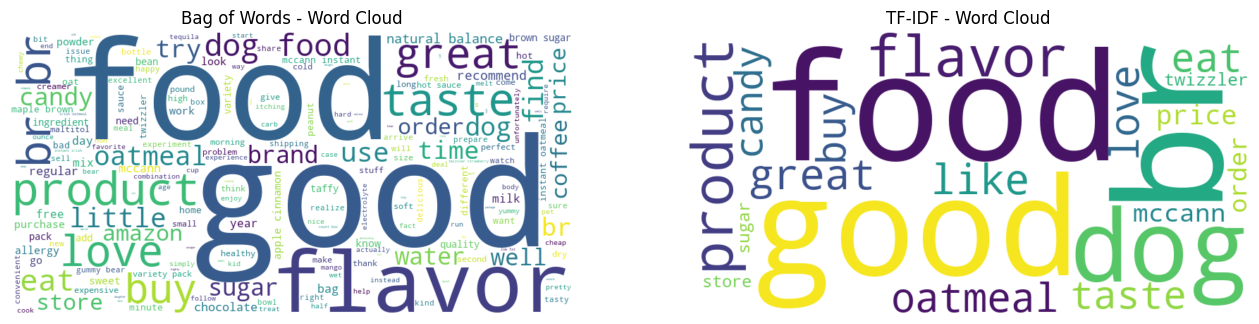

C:\Users\jimmy\AppData\Local\Temp\ipykernel_2700\3724146293.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bow_scores, y=top_bow_words, ax=axes[0], palette="viridis")
C:\Users\jimmy\AppData\Local\Temp\ipykernel_2700\3724146293.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tfidf_scores, y=top_tfidf_words, ax=axes[1], palette="magma")


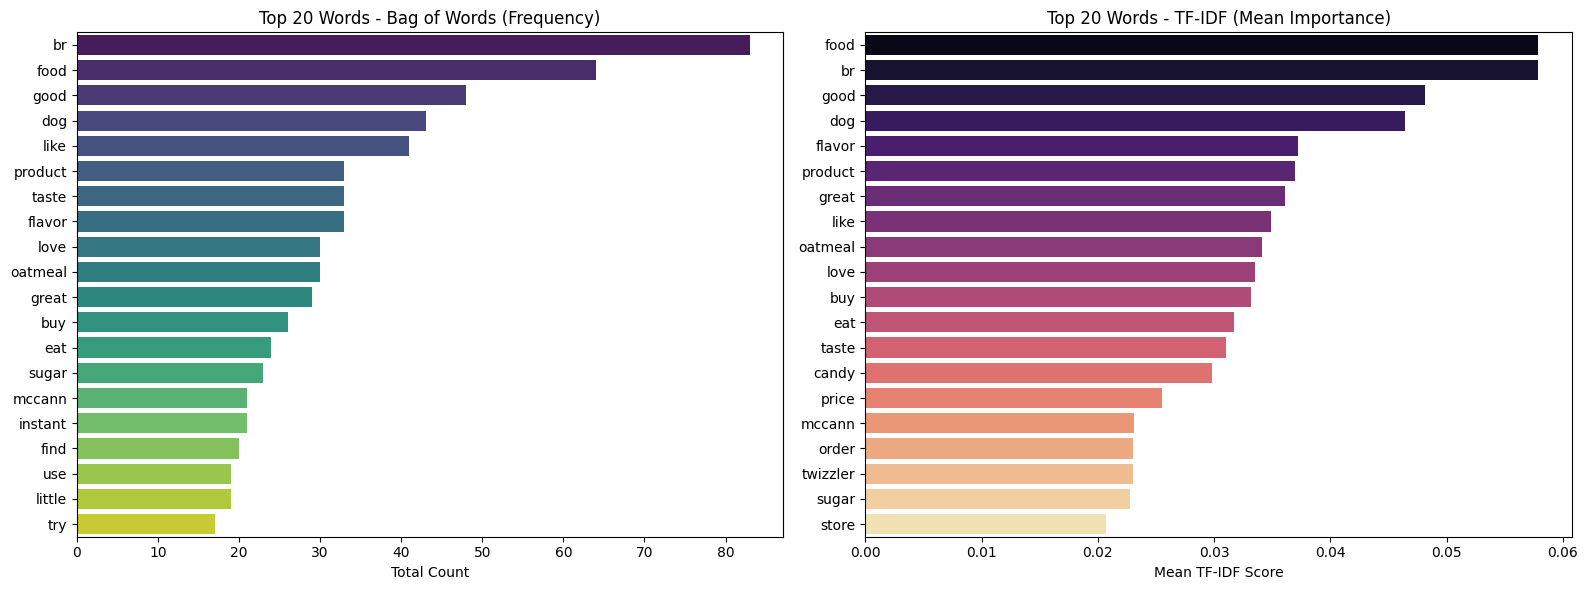

In [ ]:
# --- TASK 3: Visualization 1 ---

# 1. Word Clouds
all_cleaned_text = " ".join(df['Cleaned_Text'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BoW Word Cloud (Based on raw text frequencies)
wordcloud_bow = WordCloud(width=800, height=400, background_color='white').generate(all_cleaned_text)
axes[0].imshow(wordcloud_bow, interpolation='bilinear')
axes[0].set_title("Bag of Words - Word Cloud")
axes[0].axis('off')

# TF-IDF Word Cloud (Based on TF-IDF scores)
tfidf_dict = dict(zip(top_tfidf_words, top_tfidf_scores))
wordcloud_tfidf = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict)
axes[1].imshow(wordcloud_tfidf, interpolation='bilinear')
axes[1].set_title("TF-IDF - Word Cloud")
axes[1].axis('off')

plt.show()

# 2. Bar Charts for Top 20 Words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BoW Bar Chart
sns.barplot(x=top_bow_scores, y=top_bow_words, ax=axes[0], palette="viridis")
axes[0].set_title("Top 20 Words - Bag of Words (Frequency)")
axes[0].set_xlabel("Total Count")

# TF-IDF Bar Chart
sns.barplot(x=top_tfidf_scores, y=top_tfidf_words, ax=axes[1], palette="magma")
axes[1].set_title("Top 20 Words - TF-IDF (Mean Importance)")
axes[1].set_xlabel("Mean TF-IDF Score")

plt.tight_layout()
plt.show()

#### 4️⃣ Visualization 2: Relationship Between Review Scores and Word Usage
🔍 Investigate how word usage changes with review scores. Focus on two categories:

- Positive Reviews: Scores of 4 and 5.
- Negative Reviews: Scores of 1 and 2.

🔍 Identify the words that appear frequently in both categories, as well as those that are unique to each category.

🔠 Use word embeddings to visualize clusters of words with similar meanings in each category. For example:

- Generate word embeddings using Word2Vec or GloVe.
- Apply dimensionality reduction techniques such as PCA or t-SNE to reduce the embeddings to 2D space.
- Plot these word clusters using scatter plots, clearly differentiating between positive and negative words.
- Highlight words that are common to both categories using a distinct colour or marker.

🎯 The goal is to visually demonstrate the similarities and differences in language used in positive and negative reviews.


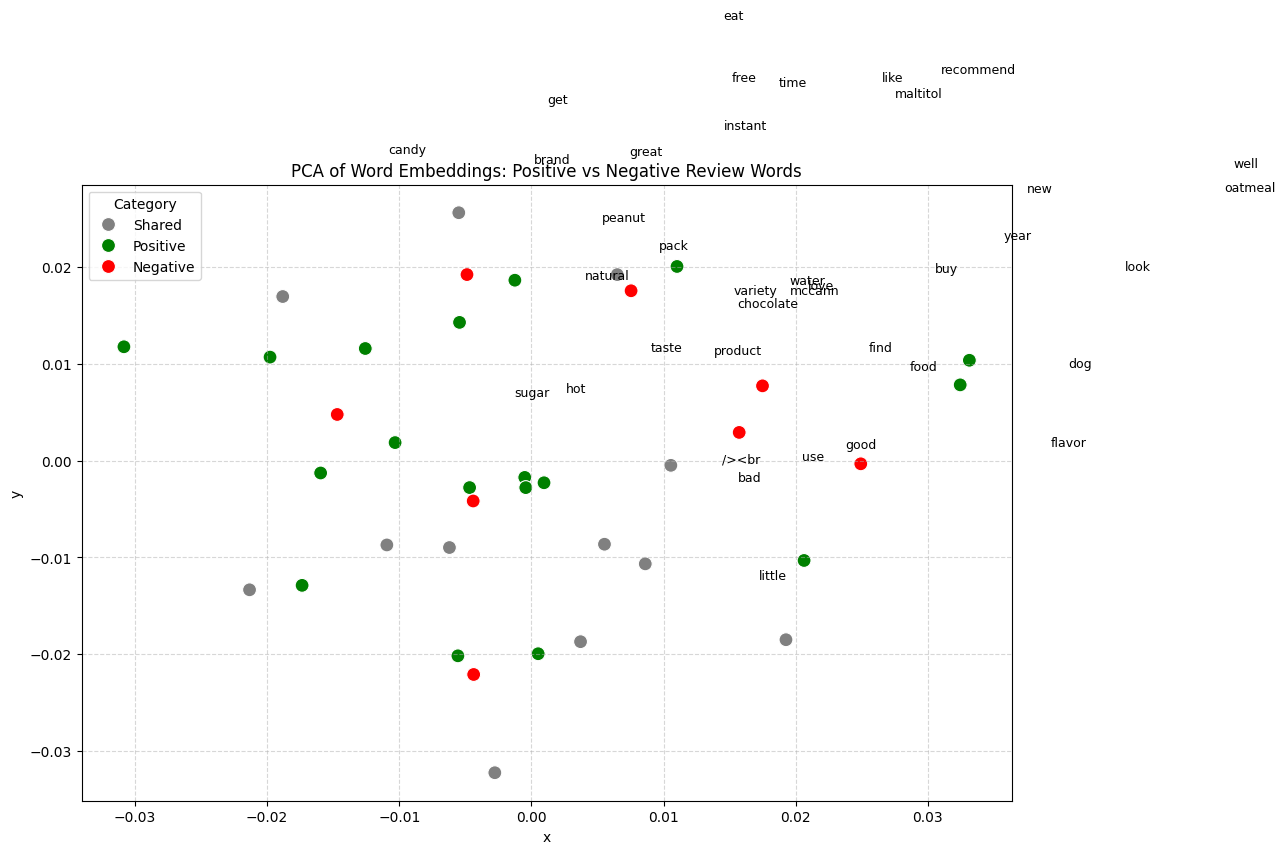

In [ ]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

# Separate into Positive and Negative reviews
positive_reviews = df[df['Score'].isin([4, 5])]['Cleaned_Text'].apply(lambda x: x.split())
negative_reviews = df[df['Score'].isin([1, 2])]['Cleaned_Text'].apply(lambda x: x.split())

# Train a Word2Vec model on all tokenized text
all_tokens = df['Cleaned_Text'].apply(lambda x: x.split()).tolist()
w2v_model = Word2Vec(sentences=all_tokens, vector_size=100, window=5, min_count=5, workers=4)

# Get top 30 words for positive and negative reviews to visualize
pos_words_flat = [word for sublist in positive_reviews for word in sublist]
neg_words_flat = [word for sublist in negative_reviews for word in sublist]

from collections import Counter
top_pos_words = [word[0] for word in Counter(pos_words_flat).most_common(30) if word[0] in w2v_model.wv]
top_neg_words = [word[0] for word in Counter(neg_words_flat).most_common(30) if word[0] in w2v_model.wv]

# Identify unique and shared words
shared_words = set(top_pos_words).intersection(set(top_neg_words))
unique_pos = set(top_pos_words) - shared_words
unique_neg = set(top_neg_words) - shared_words

# Combine words for PCA visualization
words_to_plot = list(shared_words) + list(unique_pos) + list(unique_neg)
word_vectors = np.array([w2v_model.wv[word] for word in words_to_plot])

# Apply PCA to reduce embeddings to 2D
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(word_vectors)

# Create a DataFrame for plotting
plot_df = pd.DataFrame(vectors_2d, columns=['x', 'y'])
plot_df['Word'] = words_to_plot
plot_df['Category'] = ['Shared'] * len(shared_words) + ['Positive'] * len(unique_pos) + ['Negative'] * len(unique_neg)

# Plot the PCA clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='x', y='y', hue='Category', palette={'Shared': 'gray', 'Positive': 'green', 'Negative': 'red'}, s=100)

# Add word labels to the scatter plot
for i, row in plot_df.iterrows():
    plt.text(row['x'] + 0.001, row['y'] + 0.001, row['Word'], fontsize=9, ha='left', va='bottom')

plt.title("PCA of Word Embeddings: Positive vs Negative Review Words")
plt.margins(0.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#### 5️⃣ Visualization 3: Sentiment Analysis and Temporal Trends
📝 Perform sentiment analysis on the reviews using either TF-IDF or Word Embeddings.

🏷️ Assign sentiment scores to each review based on the words used. For example:

- Use pre-trained sentiment lexicons or machine learning models to classify each review as positive, neutral, or negative.

📊 Visualize sentiment trends over time:

- If the dataset includes review dates, group reviews by month or year and calculate the average sentiment score for each time period.
- Plot these scores using line charts to show how sentiment has changed over time.

📊 Visualize sentiment distribution:
- Use heatmaps or scatter plots to show the distribution of positive, neutral, and negative reviews within the embedding space.
- Ensure that visualisations are clear, with appropriate labels and legends.

🔍

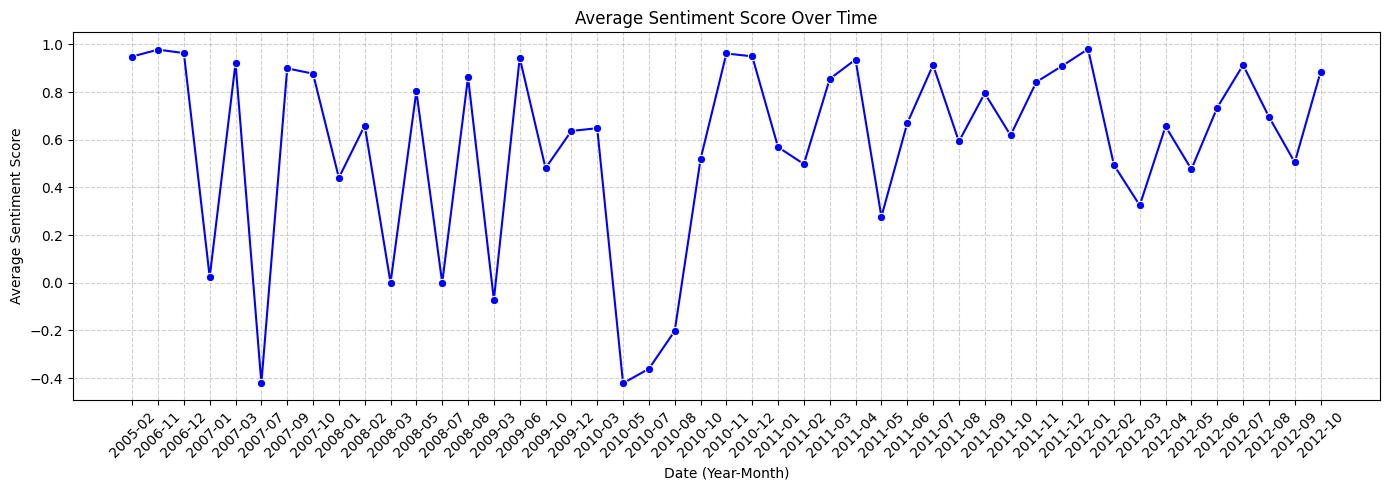

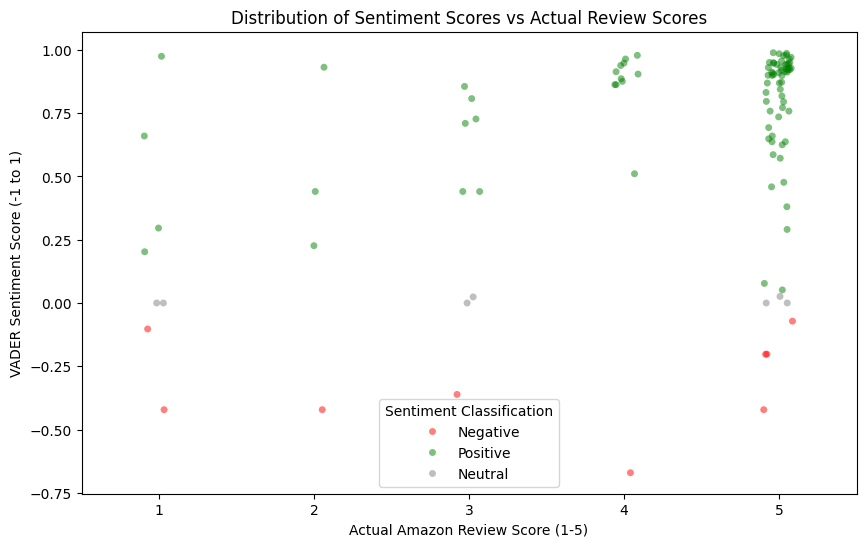

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment(text):
    return sia.polarity_scores(text)['compound']

# Assign sentiment scores
df['Sentiment_Score'] = df['Cleaned_Text'].apply(get_sentiment)

# Classify as Positive, Neutral, or Negative based on score
def classify_sentiment(score):
    if score >= 0.05: return 'Positive'
    elif score <= -0.05: return 'Negative'
    else: return 'Neutral'

df['Sentiment_Class'] = df['Sentiment_Score'].apply(classify_sentiment)

# Convert Unix timestamp 'Time' to Datetime
df['Date'] = pd.to_datetime(df['Time'], unit='s')
df['YearMonth'] = df['Date'].dt.to_period('M')

# Calculate average sentiment score over time
sentiment_over_time = df.groupby('YearMonth')['Sentiment_Score'].mean().reset_index()
sentiment_over_time['YearMonth'] = sentiment_over_time['YearMonth'].astype(str)

# Plot 1: Sentiment Trends Over Time (Line Chart)
plt.figure(figsize=(14, 5))
sns.lineplot(data=sentiment_over_time, x='YearMonth', y='Sentiment_Score', marker='o', color='b')
plt.title("Average Sentiment Score Over Time")
plt.xlabel("Date (Year-Month)")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Plot 2: Sentiment Distribution (Scatter Plot with Jitter)
plt.figure(figsize=(10, 6))
# Using a stripplot to act as a scatter plot showing distribution by actual Amazon Score
sns.stripplot(data=df, x='Score', y='Sentiment_Score', hue='Sentiment_Class', 
              palette={'Positive': 'green', 'Neutral': 'gray', 'Negative': 'red'}, 
              jitter=True, alpha=0.5)
plt.title("Distribution of Sentiment Scores vs Actual Review Scores")
plt.xlabel("Actual Amazon Review Score (1-5)")
plt.ylabel("VADER Sentiment Score (-1 to 1)")
plt.legend(title="Sentiment Classification")
plt.show()